<img src="../img/GTK_Logo_Social_Icon.jpg" width=175 align="right" />

#  Worksheet 4.3: Automate it All! - Answers
This worksheet covers concepts relating to automating a machine learning model using the techniques we learned.  It should take no more than 20-30 minutes to complete.  Please raise your hand if you get stuck.
The modules used are:
* Pandas (https://pandas.pydata.org/pandas-docs/stable/)
* Scikit-learn (https://scikit-learn.org/stable/documentation.html)
* TPOT (https://github.com/EpistasisLab/tpot2)

In [11]:
# Load Libraries - Make sure to run this cell!
import warnings
warnings.filterwarnings("ignore", message="pkg_resources is deprecated")

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from tpot import TPOTClassifier

DATA_HOME = '../data'

## Step One:  Import the Data
In this example, we're going to use the dataset we used in worksheet 4.2.  Run the following code to read in the data, extract the features and target vector.

In [12]:
df = pd.read_csv(f'{DATA_HOME}/dga_features_final_df.csv')
target = (df["isDGA"].astype(str).str.lower() == "dga").astype(int).values
feature_matrix = df.drop(['isDGA'], axis=1)

Next, perform the test/train split in the conventional manner.

In [13]:
feature_matrix_train, feature_matrix_test, target_train, target_test = train_test_split(feature_matrix, 
                                                                                        target, 
                                                                                        test_size=0.25)

## Step Two:  Run the Optimizer
In the next step, use TPOT to create a classification pipeline using the DGA data set that we have been using.  The `TPOTClassifier()` has many configuration options and in the interest of time, please set the following variables when you instantiate the classifier.

* `max_time_mins`:  In the interests of time, set this to some number < 5.
* `max_eval_time_mins`:  This is another time limiting parameter which controls the amount of time for each iteration.  Default is 60*5.
* `n_jobs`:  The number of cores to use.


**Note:  This step will take some time, so you might want to get some coffee or a snack when it is running.**  While this is running take a look at the other configuration options available here: https://epistasislab.github.io/tpot/latest/.

In [14]:
# Your code here... 
clf = TPOTClassifier(
    search_space="linear-light",
    scorers=["roc_auc"],
    scorers_weights=[1.0],
    cv=5,
    population_size=20,
    max_time_mins=3,          # <-- the lab time-box. Bump for better results.
    n_jobs=4,                # set to 1 if it hangs
    verbose=1,
)
clf.fit(feature_matrix_train, target_train)

Generation: : 102it [03:00,  1.77s/it]


,search_space,<tpot.search_...t 0x302245750>
,scorers,['roc_auc']
,cv,5
,max_time_mins,3
,n_jobs,4
,verbose,1
,scorers_weights,[1.0]
,other_objective_functions,[]
,other_objective_functions_weights,[]
,objective_function_names,None
,bigger_is_better,True


ConfusionMatrixDisplay.from_predictions(target_test, predictions)

## Step Three:  Evaluate the Performance
Now that you have a trained model, the next step is to evaluate the performance and see how TPOT did in comparison with earlier models we created.  Use the techniques you've learned to evaluate the performance of your model.  Specifically, print out the `classification report` and a confusion matrix. 

```
from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(target_test, predictions)

```

What is the accuracy of your model?  Is it significantly better than what you did in earlier labs?

In [15]:
predictions = clf.predict(feature_matrix_test)

In [16]:
print(classification_report(predictions, target_test))

              precision    recall  f1-score   support

           0       0.97      0.85      0.91       280
           1       0.84      0.96      0.90       220

    accuracy                           0.90       500
   macro avg       0.90      0.91      0.90       500
weighted avg       0.91      0.90      0.90       500



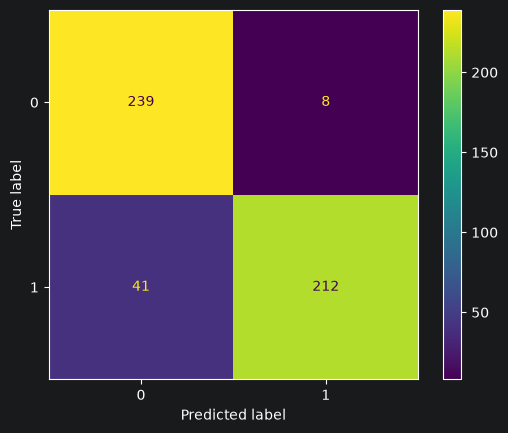

In [17]:
ConfusionMatrixDisplay.from_predictions(target_test, predictions)

## Step 4:  Export your Pipeline
If you are happy with the results from `TPOT` you can export the pipeline as a pickle with the code below:

The first option is to use the `joblib` library to save the pipeline.
```python
import joblib
joblib.dump(clf.fitted_pipeline_, "dga_pipeline.joblib")
# later / in production:
pipeline = joblib.load("dga_pipeline.joblib")
pipeline.predict(X_new)
```


In [18]:
#Try it yourself

You can view the pipeline with the code below.

In [19]:
clf.fitted_pipeline_

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('robustscaler', ...), ('variancethreshold', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](2,)","[0,1]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](6,)","['length','digits','entropy','vowel-cons','firstDigitIndex','ngrams']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,6
,"quantile_range quantile_range: tuple (q_min, q_max), 0.0 < q_min < q_max < 100.0, default=(25.0, 75.0)Quantile range used to calculate `scale_`. By default this is equal tothe IQR, i.e., `q_min` is the first quantile and `q_max` is the thirdquantile... versionadded:: 0.18","(0.2598372227484, ...)"
,"with_centering with_centering: bool, default=TrueIf `True`, center the data before scaling.This will cause :meth:`transform` to raise an exception when attemptedon sparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_scaling with_scaling: bool, default=TrueIf `True`, scale the data to interquartile range.",True


Alternatively, you can dump the pipeline to executable code with the code block below.

In [20]:
from sklearn import set_config
set_config(print_changed_only=False)   # show every parameter, not just non-defaults

code = f"""import sklearn
from sklearn.pipeline import Pipeline

pipeline = {repr(clf.fitted_pipeline_)}
"""
with open("exported_pipeline.py", "w") as f:
    f.write(code)

print(code)

import sklearn
from sklearn.pipeline import Pipeline

pipeline = Pipeline(memory=None,
         steps=[('robustscaler',
                 RobustScaler(copy=True,
                              quantile_range=(0.2598372227484, 0.7911904578074),
                              unit_variance=False, with_centering=True,
                              with_scaling=True)),
                ('variancethreshold',
                 VarianceThreshold(threshold=0.0001303942753)),
                ('featureunion-1',
                 FeatureUnion(n_jobs=None,
                              transformer_list=[('featureunion',
                                                 FeatureUnion(n_jobs=None,
                                                              trans...
                              transformer_list=[('skiptransformer',
                                                 SkipTransformer()),
                                                ('passthrough', Passthrough())],
                          